# Импорт библиотек

In [156]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка данных

In [157]:
df_train = pd.read_csv("../data/train.csv")
df_train.sort_index(inplace=True)
df_train.head(5)

,index,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,102.414420,95.757483,0.935000,5.466584,5.466584,0.719259,0.719259,0.681165,18.307692,...,1,0,0,0,0,0,0,0,0,0
1,1,0.044333,8.401080,189.500000,11.492712,11.492712,0.012350,-3.798024,0.769122,27.652174,...,0,1,0,0,0,0,0,0,0,0
2,2,4.437964,50.085589,11.285714,5.366084,5.366084,0.522930,0.522930,0.612606,24.608696,...,0,0,0,0,0,0,0,0,0,0
3,3,6.827881,682.788051,100.000000,13.317130,13.317130,0.020658,-4.829339,0.345823,12.400000,...,0,0,1,0,0,0,0,0,0,0
4,4,2.003253,70.001455,34.943894,6.320833,6.320833,0.300347,0.300347,0.562066,60.272727,...,0,0,0,0,0,0,0,0,0,0


In [158]:
df_test = pd.read_csv("../data/test.csv")
df_test.sort_index(inplace=True)
df_test.head(5)

,index,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,13.761882,13.761882,0.121946,-0.962625,0.770057,30.580645,450.541,432.397,450.070799,...,1,0,0,0,0,0,0,1,0,0
1,1,13.224489,13.224489,0.066132,-1.801871,0.278628,25.687500,448.380,428.220,448.100561,...,0,0,0,0,0,0,0,0,0,0
2,2,6.191528,6.191528,0.445278,0.445278,0.657472,55.384615,179.307,158.139,179.167400,...,0,0,0,0,0,0,0,0,0,0
3,3,14.061236,14.061236,0.054870,-6.660336,0.564307,23.464286,410.289,397.185,410.086525,...,0,0,0,0,0,0,0,0,0,0
4,4,12.790378,12.790378,0.320463,-1.642616,0.696213,22.000000,280.279,268.183,280.073559,...,0,0,0,0,0,0,0,0,0,0


Удалим ненужный признак Index

In [159]:
df_train = df_train.drop(columns="index")
df_test = df_test.drop(columns="index")

## Анализ данных

### Первичный осмотр 

In [160]:
df_train.shape  


(751, 213)

In [161]:
df_test.shape

(250, 210)

Обучающий датасет представлен 751 строкой и 214 признаками Тестовый датасет представлен 250 строками, 211 признаками. 3 дополнительных признака в обучающем набором данных обусловлены наличием трех целевых переменных. Соотношение строк train/test составляет примерно 3:1.





In [162]:
df_train.dtypes.value_counts()

float64    107
int64      106
Name: count, dtype: int64

In [163]:
df_test.dtypes.value_counts()

int64      106
float64    104
Name: count, dtype: int64

Датасеты полностью состоят из числовых данных, что упрощает их использование для большинства моделей машинного обучения без необходимости дополнительного кодирования категориальных переменных. 

### Анализ пропусков 

In [164]:
df_train.isna().sum().sum()

np.int64(24)

In [165]:
for col in df_train.columns[df_train.isna().any()]:
    missing_rows = df_train[df_train[col].isna()].index.tolist()
    print(f"Колонка '{col}': пропуски в строках {missing_rows}")

Колонка 'MaxPartialCharge': пропуски в строках [331, 500]
Колонка 'MinPartialCharge': пропуски в строках [331, 500]
Колонка 'MaxAbsPartialCharge': пропуски в строках [331, 500]
Колонка 'MinAbsPartialCharge': пропуски в строках [331, 500]
Колонка 'BCUT2D_MWHI': пропуски в строках [331, 500]
Колонка 'BCUT2D_MWLOW': пропуски в строках [331, 500]
Колонка 'BCUT2D_CHGHI': пропуски в строках [331, 500]
Колонка 'BCUT2D_CHGLO': пропуски в строках [331, 500]
Колонка 'BCUT2D_LOGPHI': пропуски в строках [331, 500]
Колонка 'BCUT2D_LOGPLOW': пропуски в строках [331, 500]
Колонка 'BCUT2D_MRHI': пропуски в строках [331, 500]
Колонка 'BCUT2D_MRLOW': пропуски в строках [331, 500]


In [166]:
df_test.isna().sum().sum()

np.int64(12)

In [167]:
for col in df_test.columns[df_test.isna().any()]:
    missing_rows = df_test[df_test[col].isna()].index.tolist()
    print(f"Колонка '{col}': пропуски в строках {missing_rows}")

Колонка 'MaxPartialCharge': пропуски в строках [193]
Колонка 'MinPartialCharge': пропуски в строках [193]
Колонка 'MaxAbsPartialCharge': пропуски в строках [193]
Колонка 'MinAbsPartialCharge': пропуски в строках [193]
Колонка 'BCUT2D_MWHI': пропуски в строках [193]
Колонка 'BCUT2D_MWLOW': пропуски в строках [193]
Колонка 'BCUT2D_CHGHI': пропуски в строках [193]
Колонка 'BCUT2D_CHGLO': пропуски в строках [193]
Колонка 'BCUT2D_LOGPHI': пропуски в строках [193]
Колонка 'BCUT2D_LOGPLOW': пропуски в строках [193]
Колонка 'BCUT2D_MRHI': пропуски в строках [193]
Колонка 'BCUT2D_MRLOW': пропуски в строках [193]


In [168]:
df_train = df_train.drop([331, 500]).reset_index(drop=True)
df_train.shape  


(749, 213)

После анализа пропусков было выявлено, что отсутствующие значения присутствуют только в небольшом числе объектов: строки 331 и 500 в обучающей выборке и строка 193 в тестовой выборке. Пропуски наблюдаются исключительно в дескрипторах, связанных с расчетом электронных характеристик и BCUT-признаков (MaxPartialCharge, MinPartialCharge, BCUT2D_* и др.), что указывает не на случайную потерю данных, а на невозможность корректного вычисления данных дескрипторов для отдельных молекул средствами RDKit.

Поскольку количество проблемных объектов в обучающей выборке крайне мало (2 из 751, менее 0.3%), их удаление является оправданным и позволяет избежать внесения шума в модель. Использование стандартной импутации (mean/median) для подобных физико-химических дескрипторов нежелательно, так как это может привести к появлению химически некорректных значений.

Для тестовой выборки удаление объектов невозможно, поэтому пропуски будут оставлены без изменений. 

### Проверка константных признаков  

In [169]:
constant_cols_train = [
    c for c in df_train.columns
    if df_train[c].nunique() == 1
]

len(constant_cols_train)

18

In [170]:
print("Constant columns train:\n")

for i, col in enumerate(constant_cols_train, 1):
    print(f"{i:>2}. {col}")

Constant columns train:

 1. NumRadicalElectrons
 2. SMR_VSA8
 3. SlogP_VSA9
 4. fr_N_O
 5. fr_SH
 6. fr_azide
 7. fr_barbitur
 8. fr_benzodiazepine
 9. fr_diazo
10. fr_dihydropyridine
11. fr_isocyan
12. fr_isothiocyan
13. fr_lactam
14. fr_nitroso
15. fr_phos_acid
16. fr_phos_ester
17. fr_prisulfonamd
18. fr_thiocyan


In [171]:
constant_cols_test = [
    c for c in df_test.columns
    if df_test[c].nunique() == 1
]

len(constant_cols_test)

22

In [172]:
print("Constant columns test:\n")

for i, col in enumerate(constant_cols_test, 1):
    print(f"{i:>2}. {col}")

Constant columns test:

 1. NumRadicalElectrons
 2. SMR_VSA8
 3. SlogP_VSA9
 4. fr_Ar_COO
 5. fr_HOCCN
 6. fr_N_O
 7. fr_SH
 8. fr_azide
 9. fr_barbitur
10. fr_benzodiazepine
11. fr_diazo
12. fr_dihydropyridine
13. fr_isocyan
14. fr_isothiocyan
15. fr_lactam
16. fr_nitroso
17. fr_phos_acid
18. fr_phos_ester
19. fr_prisulfonamd
20. fr_term_acetylene
21. fr_tetrazole
22. fr_thiocyan


В ходе EDA были выявлены константные признаки, принимающие одинаковое значение для всех объектов. Большинство из них относятся к редким функциональным группам (fr_*), отсутствующим в рассматриваемом наборе молекул. Также константными оказались некоторые специализированные дескрипторы (NumRadicalElectrons, SMR_VSA8, SlogP_VSA9).

Поскольку такие признаки не содержат вариативности и не способны разделять объекты, они не несут полезной информации для модели и подлежат удалению.

Удаление выполняется на основе обучающей выборки, после чего одинаковый набор признаков сохраняется как для train, так и для test выборки.

In [173]:
#X_train = X_train.drop(columns=constant_cols)
#X_test = X_test.drop(columns=constant_cols)

In [174]:
df_train = df_train.drop(columns=constant_cols_train)

### Проверка на дубликаты строк (полные)

In [175]:
df_train.duplicated().any()

np.True_

In [176]:
duplicates = df_train[
    df_train.duplicated(keep=False)
]

print(f"Количество полных дубликатов: {len(duplicates)}")

duplicates

Количество полных дубликатов: 28


,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_quatN,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiophene,fr_unbrch_alkane,fr_urea
57,1309.128993,1309.128993,1.000000,12.406138,12.406138,0.004468,-4.546029,0.816512,11.687500,229.157,...,0,0,0,0,0,0,0,0,0,0
66,100.001115,68.000312,0.679996,6.598611,6.598611,0.196181,0.196181,0.607378,57.000000,179.307,...,0,0,0,0,0,0,0,0,0,0
76,11.339368,22.048772,1.944444,5.382755,5.382755,0.119792,0.119792,0.651871,29.500000,317.476,...,0,0,0,0,0,0,0,0,0,0
114,15.728168,43.175363,2.745098,13.604898,13.604898,0.124007,-1.758861,0.390224,11.391304,324.254,...,0,0,0,0,0,0,0,0,0,0
135,28.958312,30.695810,1.060000,12.764026,12.764026,0.103258,-4.525895,0.345716,12.130435,345.325,...,0,0,0,0,0,0,0,0,0,0
204,83.619244,2533.916472,30.303030,8.848320,8.848320,0.261583,0.261583,0.722639,44.571429,197.322,...,0,0,0,0,0,0,0,0,0,0
220,28.958312,30.695810,1.060000,12.764026,12.764026,0.103258,-4.525895,0.345716,12.130435,345.325,...,0,0,0,0,0,0,0,0,0,0
244,83.619244,2533.916472,30.303030,8.848320,8.848320,0.261583,0.261583,0.722639,44.571429,197.322,...,0,0,0,0,0,0,0,0,0,0
245,1309.128993,1309.128993,1.000000,12.406138,12.406138,0.004468,-4.546029,0.816512,11.687500,229.157,...,0,0,0,0,0,0,0,0,0,0
260,99.997451,99.997451,1.000000,6.972222,6.972222,0.216042,0.216042,0.779406,46.411765,235.415,...,0,0,0,0,0,0,0,0,0,0


In [177]:
df_train = df_train.drop_duplicates().reset_index(drop=True)
df_train.duplicated().any()

np.False_

In [178]:
df_test.duplicated().any()


np.True_

In [179]:
duplicates = df_test[
    df_test.duplicated(keep=False)
]

print(f"Количество полных дубликатов: {len(duplicates)}")

duplicates

Количество полных дубликатов: 43


,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
1,13.224489,13.224489,0.066132,-1.801871,0.278628,25.687500,448.380,428.220,448.100561,170,...,0,0,0,0,0,0,0,0,0,0
2,6.191528,6.191528,0.445278,0.445278,0.657472,55.384615,179.307,158.139,179.167400,74,...,0,0,0,0,0,0,0,0,0,0
6,6.191528,6.191528,0.445278,0.445278,0.657472,55.384615,179.307,158.139,179.167400,74,...,0,0,0,0,0,0,0,0,0,0
8,11.118178,11.118178,0.124606,0.124606,0.683345,44.000000,195.306,174.138,195.162314,80,...,0,0,0,0,0,0,0,0,0,0
20,11.118178,11.118178,0.124606,0.124606,0.683345,44.000000,195.306,174.138,195.162314,80,...,0,0,0,0,0,0,0,0,0,0
26,11.223245,11.223245,0.368106,-0.368106,0.688236,10.523810,282.295,268.183,282.089209,106,...,0,0,0,0,0,0,0,0,0,0
37,10.786697,10.786697,0.219687,-1.268911,0.442842,32.882353,244.207,232.111,244.080769,94,...,0,0,0,0,0,0,0,0,0,0
44,10.807343,10.807343,0.053565,-0.593066,0.810440,42.947368,345.302,324.134,344.044563,106,...,0,0,0,0,0,0,0,1,0,0
51,10.807343,10.807343,0.053565,-0.593066,0.810440,42.947368,345.302,324.134,344.044563,106,...,0,0,0,0,0,0,0,1,0,0
53,12.440151,12.440151,0.189653,-4.499733,0.822191,11.687500,245.225,239.177,245.012219,84,...,0,0,0,0,0,0,0,1,0,0


В ходе анализа данных были обнаружены полные дубликаты строк как в обучающей, так и в тестовой выборке. В обучающей выборке найдено 28 полностью совпадающих объектов, а в тестовой — 43.

Для тестовой выборки дубликаты были сохранены, поскольку при формировании итогового submission необходимо получить предсказание для каждого исходного объекта. Удаление строк из test-признаков может привести к несоответствию формата ответа требованиям соревнования. В обучающей выборке они были удалены.

### Выделение групп 

In [180]:
targets = ["IC50, mM", "CC50, mM", "SI"]

# ============================================================================
# ГРУППА 1: Общие молекулярные свойства
# ============================================================================
'''
Описывают базовые физико-химические характеристики молекулы:
массу, размер, липофильность, полярность, площадь поверхности,
лекарствоподобность и общую структурную сложность.
'''

group_general_properties = [
    'qed',
    'SPS',
    'MolWt',
    'HeavyAtomMolWt',
    'ExactMolWt',
    'NumValenceElectrons',
    'MolLogP',
    'MolMR',
    'TPSA',
    'LabuteASA',
    'HeavyAtomCount',
    'FractionCSP3',

    'NHOHCount',
    'NOCount',
    'NumHAcceptors',
    'NumHDonors',
    'NumHeteroatoms',
    'NumRotatableBonds'
]

# ============================================================================
# ГРУППА 2: Электронные и зарядовые характеристики
# ============================================================================
'''
Описывают распределение электронной плотности и зарядов в молекуле.
PEOE_VSA дескрипторы характеризуют распределение поверхности
по диапазонам частичных зарядов.
'''

group_electronic_charge = [
    'MaxPartialCharge',
    'MinPartialCharge',
    'MaxAbsPartialCharge',
    'MinAbsPartialCharge',
]

group_peoe_vsa = [
    c for c in df_train.columns
    if c.startswith("PEOE_VSA")
]

# ============================================================================
# ГРУППА 3: Топологические и структурные дескрипторы
# ============================================================================
'''
Описывают форму, связность и сложность молекулярного графа.
Chi-дескрипторы характеризуют связность,
Kappa — разветвлённость и цикличность,
BalabanJ и BertzCT — топологическую сложность молекулы.
'''

group_kappa = [
    c for c in df_train.columns
    if c.startswith("Kappa")
]

group_chi = [
    c for c in df_train.columns
    if c.startswith("Chi")
]

group_ring_descriptors = [
    'RingCount',

    'NumAliphaticCarbocycles',
    'NumAliphaticHeterocycles',
    'NumAliphaticRings',

    'NumAromaticCarbocycles',
    'NumAromaticHeterocycles',
    'NumAromaticRings',

    'NumSaturatedCarbocycles',
    'NumSaturatedHeterocycles',
    'NumSaturatedRings',
]

group_topological_structural = [

    'AvgIpc',
    'BalabanJ',
    'BertzCT',
    'HallKierAlpha',
    'Ipc',

    *group_kappa,
    *group_chi,
    *group_ring_descriptors
]

# ============================================================================
# ГРУППА 4: Поверхностные дескрипторы (VSA)
# ============================================================================
'''
Описывают распределение ван-дер-ваальсовой поверхности молекулы
по различным физико-химическим свойствам.

• SlogP_VSA  — распределение липофильности
• SMR_VSA    — распределение молярной рефрактивности
• EState_VSA — распределение EState по поверхности
• VSA_EState — распределение поверхности по уровням EState
'''

group_slogp_vsa = [
    c for c in df_train.columns
    if c.startswith("SlogP_VSA")
]

group_smr_vsa = [
    c for c in df_train.columns
    if c.startswith("SMR_VSA")
]

group_estate_vsa = [
    c for c in df_train.columns
    if c.startswith("EState_VSA")
]

group_vsa_estate = [
    c for c in df_train.columns
    if c.startswith("VSA_EState")
]

group_surface_vsa = [
    *group_slogp_vsa,
    *group_smr_vsa,
    *group_estate_vsa,
    *group_vsa_estate
]

# ============================================================================
# ГРУППА 5: Функциональные группы
# ============================================================================
'''
Признаки, отражающие количество функциональных групп
и химических фрагментов в молекуле.
Используются для SAR/QSAR анализа.
'''

group_functional_groups = [
    c for c in df_train.columns
    if c.startswith("fr_")
]

# ============================================================================
# ГРУППА 6: Специфические дескрипторы
# ============================================================================
'''
Включает специализированные хемоинформатические дескрипторы:

• EState indices —
  электротопологические индексы

• BCUT2D —
  спектральные дескрипторы молекулярного графа

• FpDensityMorgan —
  плотность Morgan fingerprints
'''

group_estate_indices = [
    'MaxAbsEStateIndex',
    'MaxEStateIndex',
    'MinAbsEStateIndex',
    'MinEStateIndex',
]

group_bcut = [
    c for c in df_train.columns
    if c.startswith("BCUT2D")
]

group_morgan_density = [
    c for c in df_train.columns
    if c.startswith("FpDensityMorgan")
]

group_specific_descriptors = [
    *group_estate_indices,
    *group_bcut,
    *group_morgan_density
]

# ============================================================================
# ИТОГОВЫЙ СЛОВАРЬ ГРУПП
# ============================================================================

feature_groups = {
    "general_properties": group_general_properties,
    "electronic_charge": group_electronic_charge,
    "peoe_vsa": group_peoe_vsa,
    "topological_structural": group_topological_structural,
    "surface_vsa": group_surface_vsa,
    "functional_groups": group_functional_groups,
    "specific_descriptors": group_specific_descriptors,
}

# ============================================================================
# ПРОВЕРКА РАЗМЕРОВ ГРУПП
# ============================================================================

for group_name, cols in feature_groups.items():
    print(f"{group_name}: {len(cols)}")

general_properties: 18
electronic_charge: 4
peoe_vsa: 14
topological_structural: 30
surface_vsa: 41
functional_groups: 70
specific_descriptors: 15


# Анализ групп 

## Целевые переменные 

In [181]:
si_reconstructed = (
    df_train["CC50, mM"] /
    df_train["IC50, mM"]
)

error = (
    si_reconstructed - df_train["SI"]
)

print(error.abs().max())

2.000888343900442e-11


было установлено, что целевая переменная SI полностью определяется отношением: IC50 и CC50
	​


Таким образом, SI не является независимой переменной и может быть восстановлена после предсказания IC50 и CC50, что позволяет отказаться от обучения отдельной модели для SI.

In [182]:
df_train[targets].describe().T

,count,mean,std,min,25%,50%,75%,max
"IC50, mM",734.0,204.596245,369.984327,0.003517,12.980039,44.000848,208.837909,4095.188563
"CC50, mM",734.0,576.660838,636.705040,0.700808,99.999036,399.307595,876.339067,4538.976189
SI,734.0,90.840834,797.887420,0.011489,1.552172,4.045156,17.010199,15620.600000


Для всех targets среднее значение существенно превышает медиану, что свидетельствует о наличии длинного правого хвоста распределения и экстремальных выбросов.

Наиболее нестабильной переменной оказался индекс селективности SI, для которого наблюдается очень высокая дисперсия и экстремальные максимальные значения. Это объясняется тем, что SI вычисляется как отношение CC50 / IC50, вследствие чего даже небольшие значения IC50 приводят к резкому росту SI.

In [183]:
df_train[targets].skew()

IC50, mM     3.825601
CC50, mM     2.089391
SI          15.456623
dtype: float64

Анализ коэффициента асимметрии (skewness) показал, что все целевые переменные обладают выраженной правосторонней асимметрией распределения. Полученные результаты подтверждают необходимость применения логарифмического преобразования (log1p) перед обучением моделей, поскольку оно позволяет уменьшить асимметрию распределений и стабилизировать масштаб целевых переменных.

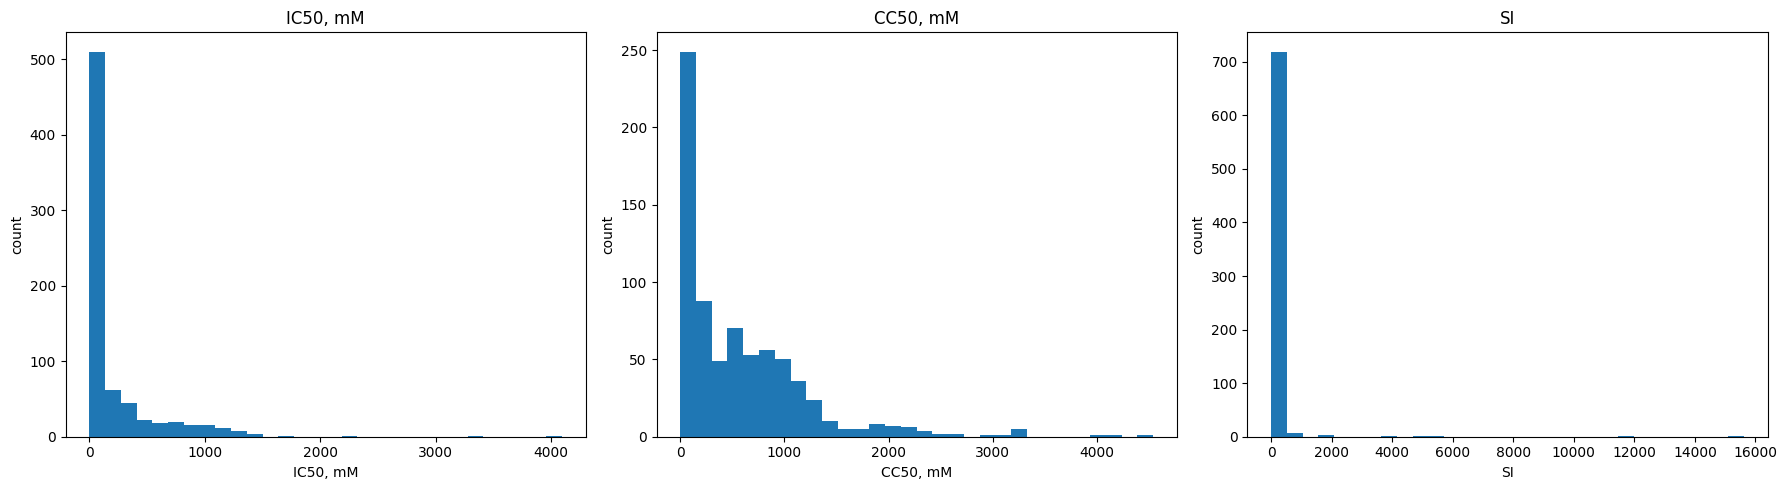

In [184]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, target in zip(axes, targets):

    ax.hist(df_train[target], bins=30)

    ax.set_title(target)
    ax.set_xlabel(target)
    ax.set_ylabel("count")

plt.tight_layout()
plt.show()

In [185]:
for target in targets:
    df_train[f"log_{target}"] = np.log1p(df_train[target])

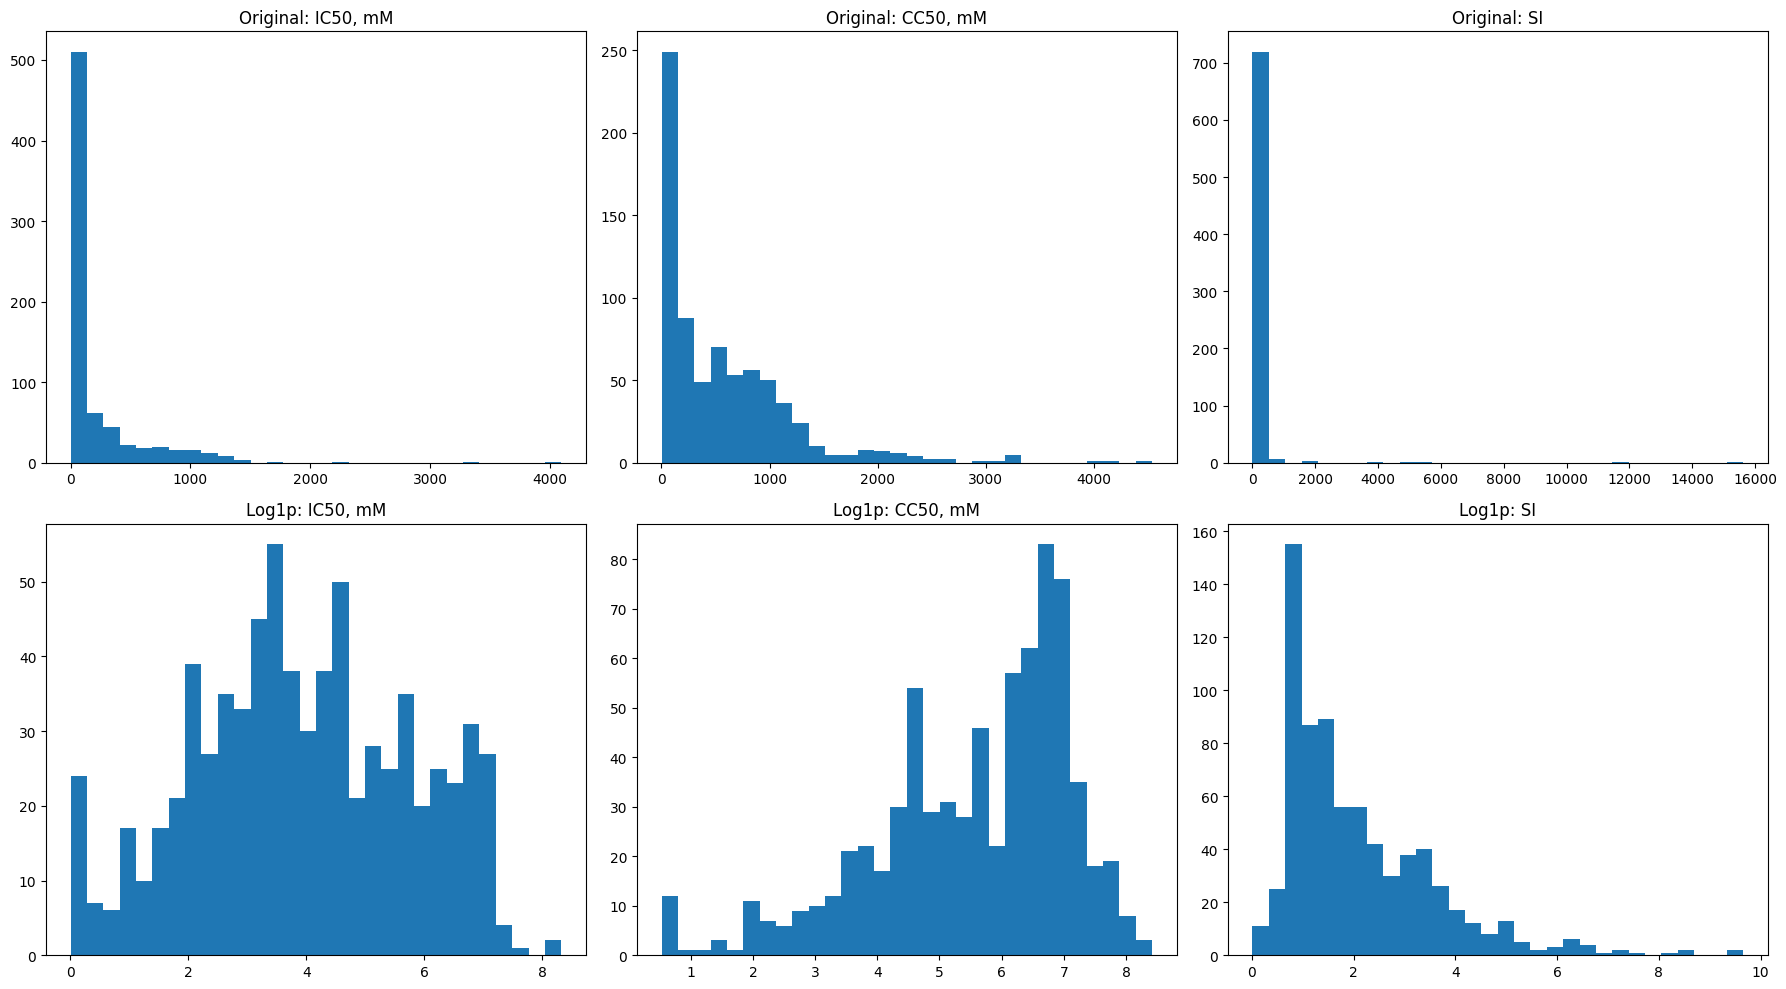

In [186]:
log_targets = [
    f"log_{t}"
    for t in targets
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, target in enumerate(targets):

    axes[0, i].hist(df_train[target], bins=30)
    axes[0, i].set_title(f"Original: {target}")

    axes[1, i].hist(df_train[f"log_{target}"], bins=30)
    axes[1, i].set_title(f"Log1p: {target}")

plt.tight_layout()
plt.show()

Логарифмическое преобразование log1p существенно уменьшает асимметрию распределений и делает их ближе к нормальным, что потенциально улучшает стабильность и качество моделей регрессии.

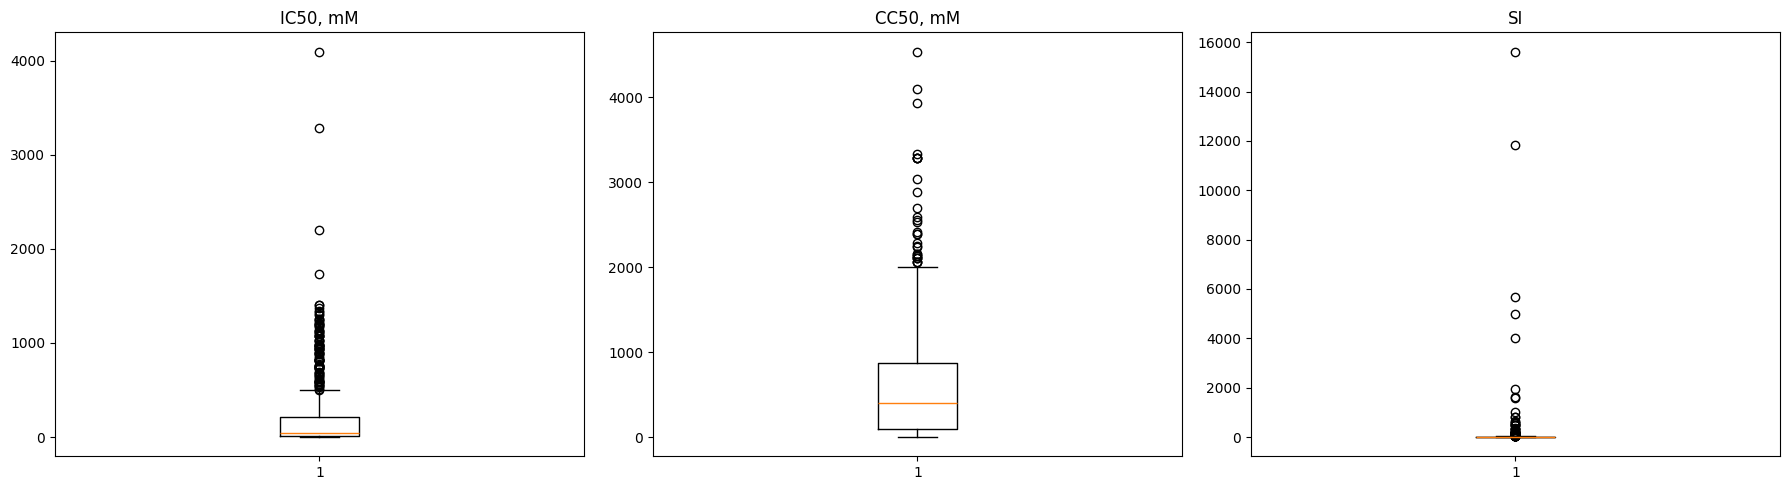

In [187]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, target in zip(axes, targets):

    ax.boxplot(df_train[target])

    ax.set_title(target)

plt.tight_layout()
plt.show()

Boxplot-анализ подтвердил наличие большого количества выбросов во всех целевых переменных.

Для IC50 наблюдается значительное число экстремально высоких значений, существенно превышающих межквартильный диапазон. Аналогичная ситуация наблюдается для CC50, однако распределение токсичности выглядит более стабильным и менее асимметричным по сравнению с IC50.

Наиболее выраженные выбросы характерны для индекса селективности SI. Большинство значений сосредоточено в области низких значений, однако присутствует небольшое количество экстремально больших наблюдений, достигающих значений свыше 15000. Это приводит к сильному растяжению масштаба распределения и подтверждает ранее выявленную высокую асимметрию (skewness = 15.46).  
  
Полученные результаты дополнительно подтверждают необходимость:

- применения логарифмического преобразования (log1p);
- использования устойчивых к выбросам моделей;
- отказа от прямого моделирования SI как независимой целевой переменной.  

## ГРУППА 1: Общие молекулярные свойства

In [188]:
df_train[group_general_properties].describe().T

,count,mean,std,min,25%,50%,75%,max
qed,734.0,0.577539,0.214745,0.059567,0.442842,0.636073,0.742913,0.947265
SPS,734.0,29.511426,12.575387,9.545455,18.489865,29.240625,38.805147,60.272727
MolWt,734.0,354.749881,129.404943,110.156000,267.253000,321.322500,414.539000,904.777000
HeavyAtomMolWt,734.0,330.626546,124.350414,100.076000,249.385000,298.212500,389.961250,856.393000
ExactMolWt,734.0,354.420519,129.258592,110.073165,267.067871,321.125175,414.215518,904.248467
NumValenceElectrons,734.0,134.479564,47.309598,42.000000,104.000000,124.000000,156.000000,350.000000
MolLogP,734.0,3.482117,2.138025,-5.750700,2.450600,3.437250,4.573350,12.822200
MolMR,734.0,96.015454,34.898844,28.088500,74.058925,87.608350,112.632725,236.253400
TPSA,734.0,62.274673,46.549829,0.000000,29.460000,50.950000,85.487500,407.500000
LabuteASA,734.0,149.405794,53.429317,46.234269,115.151513,134.682213,174.976492,353.328713


Группа general_properties описывает базовые физико-химические характеристики молекул: массу, липофильность, полярность, площадь поверхности, количество гетероатомов и способность к образованию водородных связей. Большинство признаков имеют асимметричные распределения с длинными правыми хвостами, что характерно для химических дескрипторов. Особенно это заметно для MolWt, MolMR, TPSA, LabuteASA и NumRotatableBonds, где присутствуют молекулы с существенно большими значениями относительно основной массы выборки. Некоторые признаки (qed, FractionCSP3) распределены более компактно и ограничены фиксированными диапазонами. Также наблюдаются выбросы, однако они, вероятнее всего, отражают реальные особенности отдельных химических структур, а не ошибки данных.

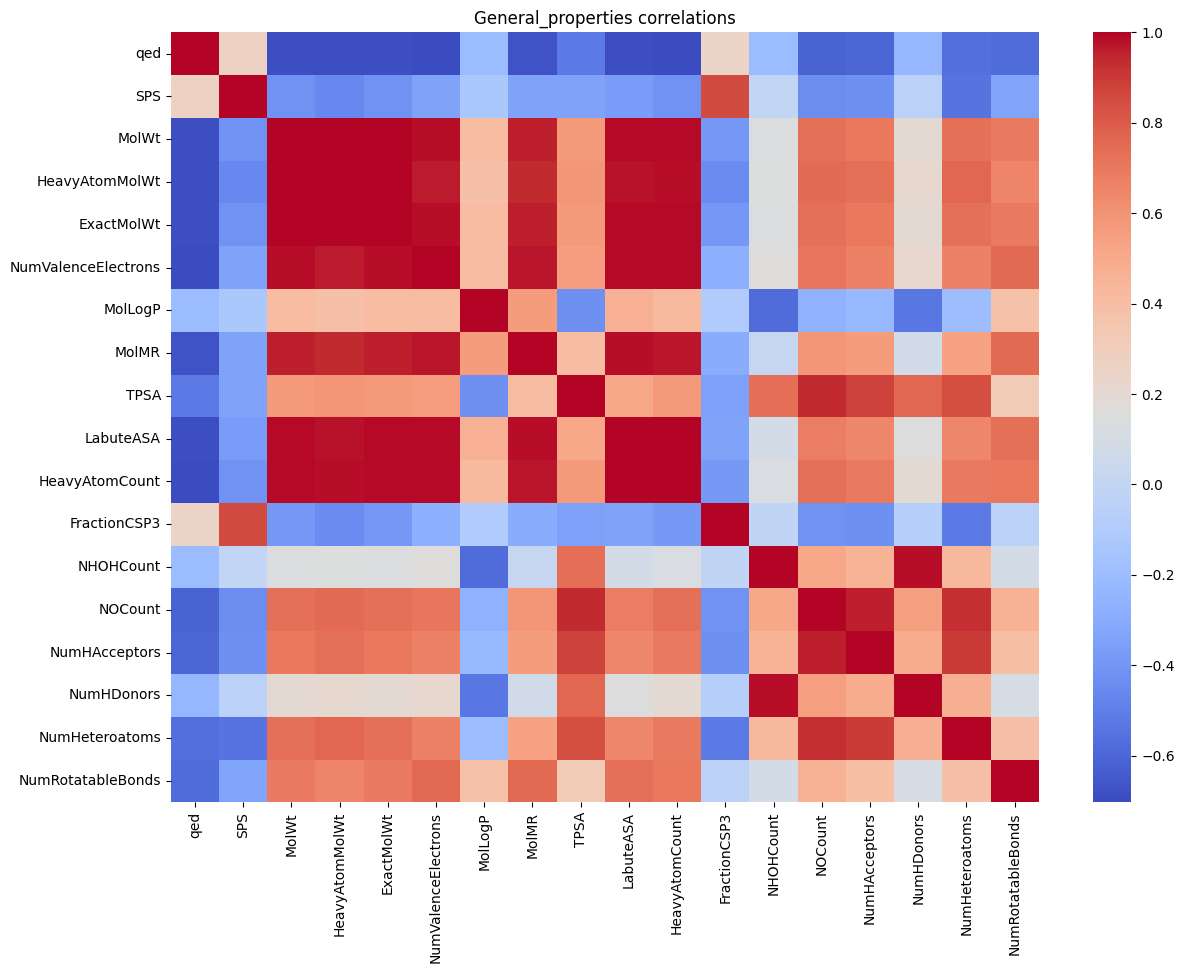

In [189]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    df_train[group_general_properties].corr(),
    cmap="coolwarm"
)

plt.title("General_properties correlations")

plt.show()

Корреляционная матрица показывает выраженную мультиколлинеарность между признаками, связанными с размером и составом молекулы. Практически идеальные корреляции наблюдаются между MolWt, ExactMolWt, HeavyAtomMolWt, HeavyAtomCount и NumValenceElectrons, что объясняется тем, что все эти признаки описывают молекулярный размер и атомный состав. Высокие корреляции также присутствуют между MolMR, LabuteASA, TPSA и количеством гетероатомов. Кроме того, признаки водородных связей (NHOHCount, NumHDonors, NumHAcceptors) тесно связаны с TPSA и NumHeteroatoms. Таким образом, внутри группы присутствует значительная избыточность информации, и часть признаков потенциально может быть удалена при построении линейных моделей.

In [190]:
for target in [
    "log_IC50, mM",
    "log_CC50, mM"
]:

    corr = (
        df_train[group_general_properties]
        .corrwith(df_train[target])
        .sort_values(key=abs, ascending=False)
    )

    print(f"\n{target}")
    print(corr)


log_IC50, mM
NumRotatableBonds     -0.189291
NHOHCount             -0.142701
FractionCSP3          -0.136527
MolLogP               -0.098413
NumHDonors            -0.097710
MolMR                 -0.083015
NumHeteroatoms         0.079810
NumValenceElectrons   -0.059019
NumHAcceptors          0.055867
LabuteASA             -0.053112
NOCount                0.045175
qed                    0.039491
HeavyAtomCount        -0.034777
MolWt                 -0.033303
ExactMolWt            -0.033250
SPS                   -0.021800
HeavyAtomMolWt        -0.016242
TPSA                  -0.005053
dtype: float64

log_CC50, mM
NHOHCount             -0.178880
MolMR                 -0.174498
NumValenceElectrons   -0.167560
LabuteASA             -0.165913
NumRotatableBonds     -0.161681
HeavyAtomCount        -0.159703
MolWt                 -0.159026
ExactMolWt            -0.159011
HeavyAtomMolWt        -0.152280
NumHDonors            -0.147155
MolLogP               -0.118853
TPSA                  -0.1050

Корреляции признаков группы general_properties с целевыми переменными log(IC50) и log(CC50) в целом невысоки (|r| < 0.2), однако некоторые тенденции прослеживаются достаточно стабильно. Наиболее выраженную отрицательную связь с log(IC50) показывает NumRotatableBonds (r ≈ -0.19), а также NHOHCount и FractionCSP3. Это может указывать на связь гибкости молекулы и наличия гидроксильных групп с повышением биологической активности. Для log(CC50) наиболее заметные отрицательные корреляции наблюдаются у NHOHCount, MolMR, NumValenceElectrons, LabuteASA и молекулярной массы, что может свидетельствовать о связи увеличения размера и поляризуемости молекулы с токсичностью. Несмотря на слабые линейные зависимости, данные признаки остаются важными для QSAR-моделей и могут быть особенно полезны в составе нелинейных алгоритмов машинного обучения.

In [191]:
mass_corr_cols = [
    'ExactMolWt',
    'HeavyAtomMolWt'
]

df_train = df_train.drop(columns=mass_corr_cols, errors='ignore')

## ГРУППА 2: Электронные и зарядовые характеристики

## electronic_charge 

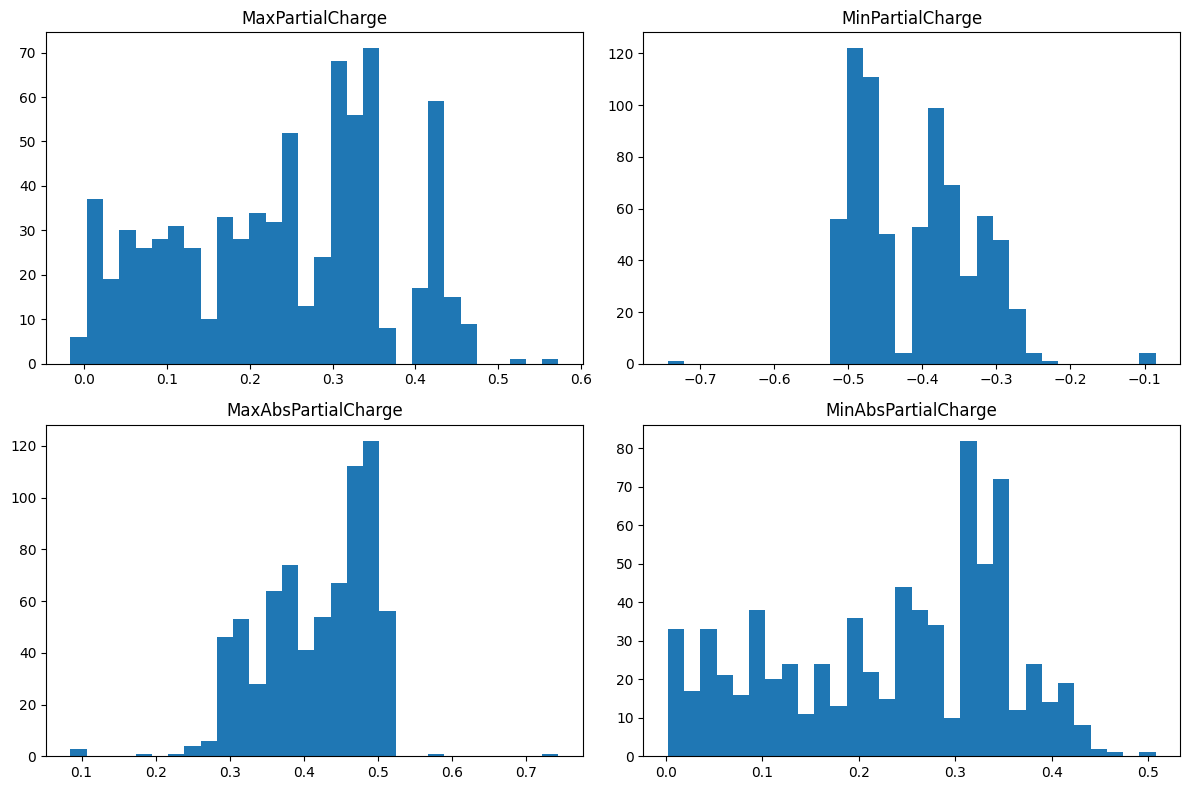

In [192]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(axes.flatten(), group_electronic_charge):

    ax.hist(df_train[col], bins=30)

    ax.set_title(col)

plt.tight_layout()
plt.show()

In [193]:
corr_electronic = (
    df_train[group_electronic_charge]
    .corr()
)

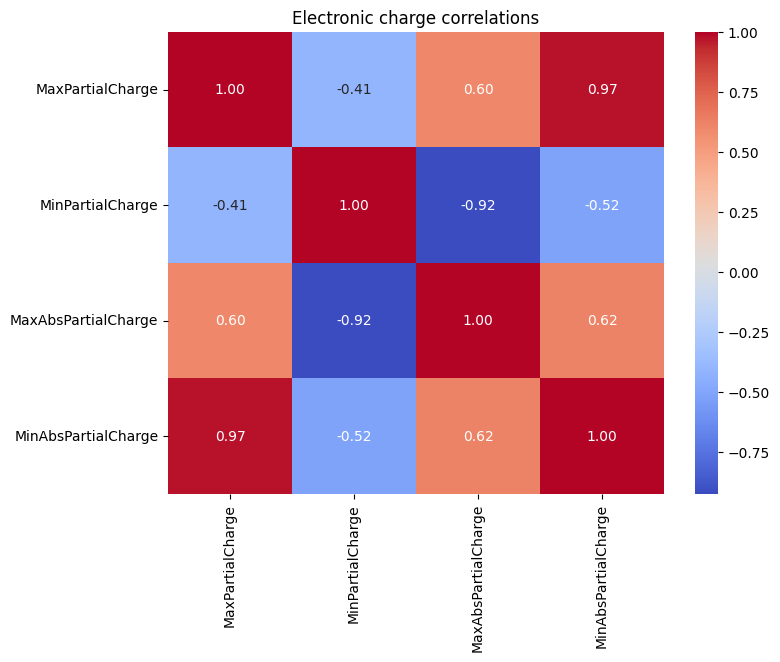

In [194]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_electronic,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Electronic charge correlations")

plt.show()

In [195]:
for target in [
    "log_IC50, mM",
    "log_CC50, mM"
]:

    corr = (
        df_train[group_electronic_charge]
        .corrwith(df_train[target])
        .sort_values(key=abs, ascending=False)
    )

    print(f"\n{target}")
    print(corr)


log_IC50, mM
MaxPartialCharge       0.077788
MinAbsPartialCharge    0.069303
MaxAbsPartialCharge    0.040405
MinPartialCharge      -0.015899
dtype: float64

log_CC50, mM
MaxAbsPartialCharge   -0.053446
MinAbsPartialCharge   -0.050943
MaxPartialCharge      -0.050787
MinPartialCharge       0.043853
dtype: float64


Анализ электронных и зарядовых дескрипторов показал наличие выраженной внутренней корреляции между признаками, особенно между MaxPartialCharge и MinAbsPartialCharge (r ≈ 0.97), а также между MinPartialCharge и MaxAbsPartialCharge (r ≈ -0.92). Это объясняется их математической зависимостью и отражает высокую степень мультиколлинеарности внутри группы.

Распределения признаков соответствуют их химическому смыслу: MaxPartialCharge характеризует наиболее электронодефицитные участки молекулы, тогда как MinPartialCharge описывает наиболее электроноизбыточные атомы.

Корреляционный анализ с целевыми переменными (log(IC50) и log(CC50)) показал относительно слабые линейные зависимости (|r| < 0.1), что свидетельствует об отсутствии сильного самостоятельного влияния отдельных зарядовых дескрипторов на биологическую активность и токсичность соединений.

Тем не менее, данные признаки могут содержать важную нелинейную информацию и быть полезными для ансамблевых моделей градиентного бустинга и других нелинейных алгоритмов QSAR-моделирования.

In [196]:
charge_corr_cols = [
    'MaxAbsPartialCharge',
    'MinAbsPartialCharge'
]

df_train = df_train.drop(columns=charge_corr_cols)

In [197]:
df_train[group_peoe_vsa].describe().T

,count,mean,std,min,25%,50%,75%,max
PEOE_VSA1,734.0,12.887273,11.938907,0.0,5.316789,10.006437,15.294268,118.909965
PEOE_VSA10,734.0,8.408433,13.066023,0.0,0.000000,5.702806,11.667418,107.923797
PEOE_VSA11,734.0,4.982066,8.802470,0.0,0.000000,0.000000,5.783245,47.413913
PEOE_VSA12,734.0,3.607648,5.640289,0.0,0.000000,0.000000,5.907180,29.507868
PEOE_VSA13,734.0,1.169798,2.661571,0.0,0.000000,0.000000,0.000000,17.721539
PEOE_VSA14,734.0,3.034588,4.024315,0.0,0.000000,0.000000,5.969305,23.943886
PEOE_VSA2,734.0,6.183236,6.016863,0.0,0.000000,4.794537,9.589074,34.192377
PEOE_VSA3,734.0,3.064769,5.124257,0.0,0.000000,0.000000,4.794537,43.457663
PEOE_VSA4,734.0,3.011816,6.736348,0.0,0.000000,0.000000,0.000000,44.612417
PEOE_VSA5,734.0,1.709227,4.332124,0.0,0.000000,0.000000,0.000000,23.523770


Дескрипторы PEOE_VSA* имеют сильно асимметричные распределения с длинными правыми хвостами и большим количеством нулевых значений. Для части признаков (PEOE_VSA11–14) медиана равна нулю, что указывает на отсутствие соответствующих зарядовых областей у значительной части молекул. Одновременно признаки PEOE_VSA6–9 имеют высокие средние значения и присутствуют практически во всех соединениях. В распределениях наблюдаются выбросы, однако они, вероятнее всего, отражают реальные химические особенности отдельных молекул, а не ошибки данных, поэтому удаление выбросов на текущем этапе не требуется.

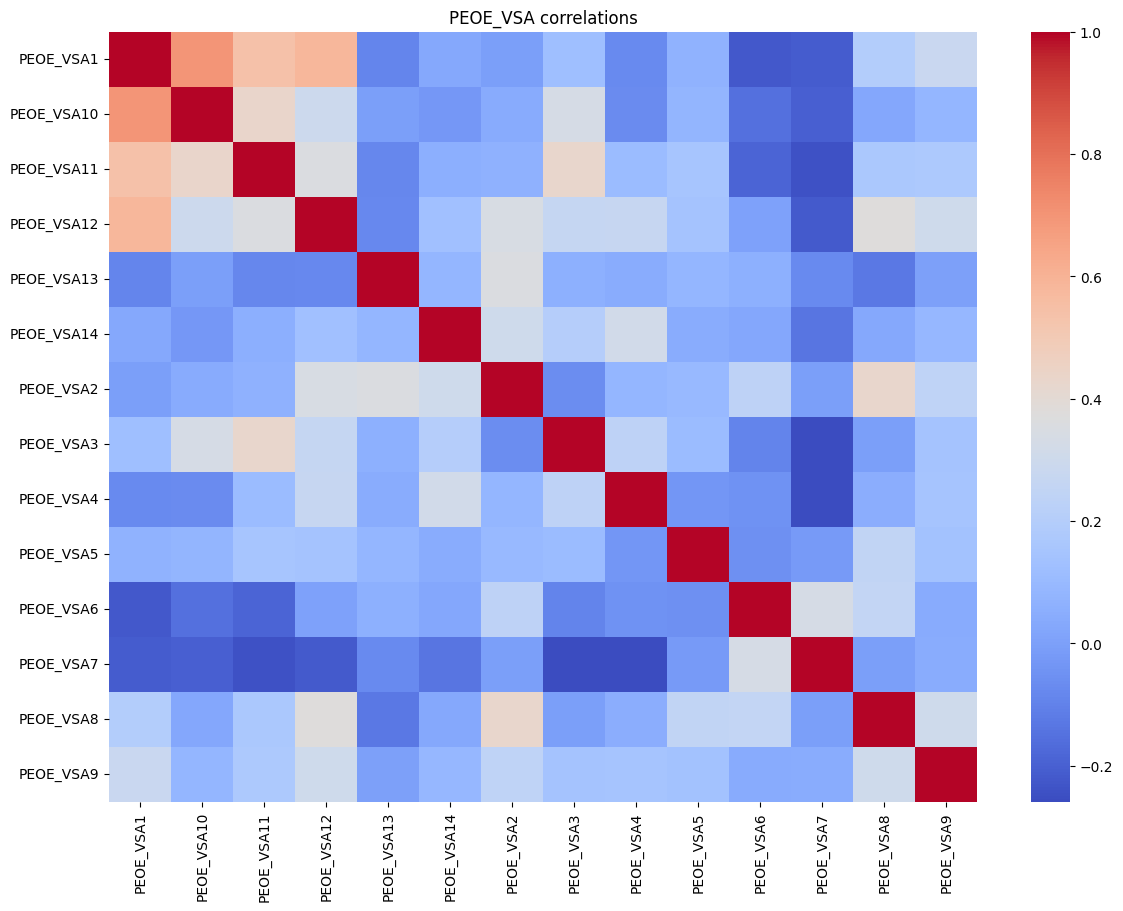

In [198]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    df_train[group_peoe_vsa].corr(),
    cmap="coolwarm"
)

plt.title("PEOE_VSA correlations")

plt.show()

Корреляционный анализ показал наличие умеренных взаимосвязей между отдельными PEOE_VSA-дескрипторами. Наиболее заметные корреляции наблюдаются между соседними бинами распределения поверхности, например между PEOE_VSA1 и PEOE_VSA10, а также между PEOE_VSA1 и PEOE_VSA12. При этом сильной мультиколлинеарности (|r| > 0.95) внутри группы не обнаружено. Это означает, что признаки содержат различающуюся информацию и могут быть сохранены для дальнейшего моделирования без дополнительного удаления.

In [199]:
for target in [
    "log_IC50, mM",
    "log_CC50, mM"
]:

    corr = (
        df_train[group_peoe_vsa]
        .corrwith(df_train[target])
        .sort_values(key=abs, ascending=False)
    )

    print(f"\n{target}")
    print(corr)


log_IC50, mM
PEOE_VSA7    -0.166654
PEOE_VSA6    -0.153191
PEOE_VSA4     0.093943
PEOE_VSA13    0.093381
PEOE_VSA9     0.083836
PEOE_VSA10    0.058864
PEOE_VSA12    0.043843
PEOE_VSA11    0.041310
PEOE_VSA5     0.034013
PEOE_VSA14    0.019837
PEOE_VSA2     0.018508
PEOE_VSA8     0.018475
PEOE_VSA3    -0.017391
PEOE_VSA1     0.016536
dtype: float64

log_CC50, mM
PEOE_VSA7    -0.185077
PEOE_VSA6    -0.181180
PEOE_VSA14   -0.094300
PEOE_VSA2    -0.065608
PEOE_VSA1    -0.059857
PEOE_VSA9     0.040866
PEOE_VSA8     0.037414
PEOE_VSA3    -0.033941
PEOE_VSA10   -0.028940
PEOE_VSA5     0.027711
PEOE_VSA13   -0.024584
PEOE_VSA11   -0.007803
PEOE_VSA4     0.006622
PEOE_VSA12   -0.005155
dtype: float64


Корреляции PEOE_VSA-дескрипторов с целевыми переменными log(IC50) и log(CC50) оказались невысокими по абсолютной величине (|r| < 0.2). Наиболее выраженные отрицательные связи наблюдаются для PEOE_VSA6 и PEOE_VSA7, что может указывать на связь определённых зарядовых поверхностей с биологической активностью и токсичностью молекул. Несмотря на слабые линейные корреляции, данные признаки потенциально остаются информативными для нелинейных моделей машинного обучения

## ГРУППА 3: Топологические и структурные дескрипторы

In [200]:
df_train[group_topological_structural].describe().T

,count,mean,std,min,25%,50%,75%,max
AvgIpc,734.0,2.831865e+00,4.387505e-01,1.787472e+00,2.494928,2.826138,3.101726e+00,3.952629e+00
BalabanJ,734.0,1.833928e+00,4.547298e-01,2.338384e-07,1.505115,1.822677,2.068673e+00,3.793185e+00
BertzCT,734.0,7.729932e+02,4.506034e+02,1.283485e+02,418.368869,670.360881,1.023798e+03,2.263926e+03
HallKierAlpha,734.0,-1.941707e+00,1.411650e+00,-6.520000e+00,-2.957500,-1.610000,-8.000000e-01,1.400000e-01
Ipc,734.0,6.474338e+10,1.466571e+12,1.071072e+02,22957.278381,135383.297709,6.594483e+06,3.951781e+13
Kappa1,734.0,1.732530e+01,6.463211e+00,4.539509e+00,13.064322,15.986869,1.991788e+01,4.690862e+01
Kappa2,734.0,6.530884e+00,3.071374e+00,1.335792e+00,4.447829,5.781911,7.639130e+00,2.037498e+01
Kappa3,734.0,3.168935e+00,1.780090e+00,4.449853e-01,2.014551,2.754876,3.894049e+00,1.266626e+01
Chi0,734.0,1.797945e+01,6.417206e+00,5.560478e+00,13.742276,16.569809,2.092677e+01,4.576397e+01
Chi0n,734.0,1.477184e+01,5.213717e+00,4.112077e+00,11.371273,13.595762,1.675140e+01,3.598698e+01


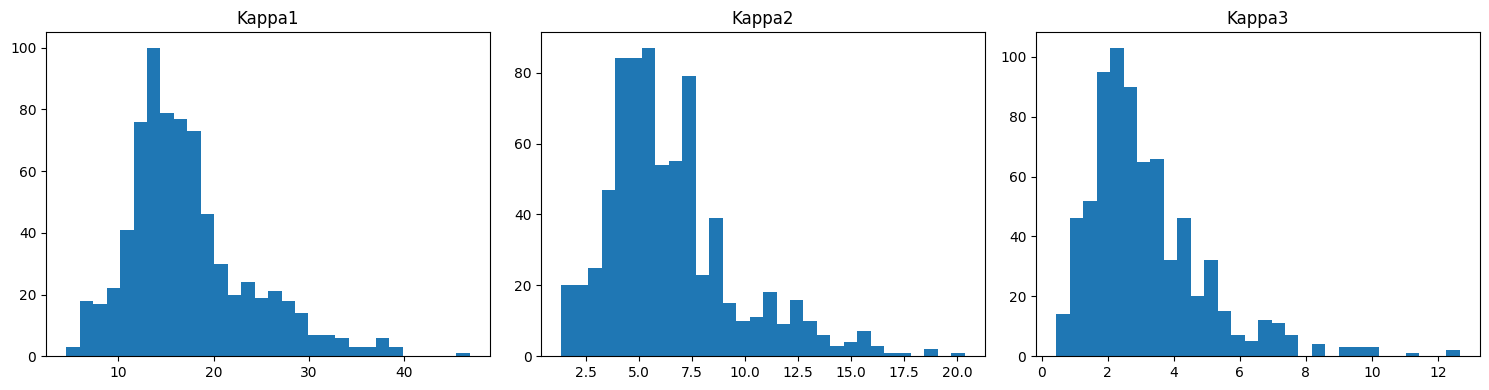

In [201]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes.flatten(), group_kappa):

    ax.hist(df_train[col], bins=30)

    ax.set_title(col)

plt.tight_layout()
plt.show()

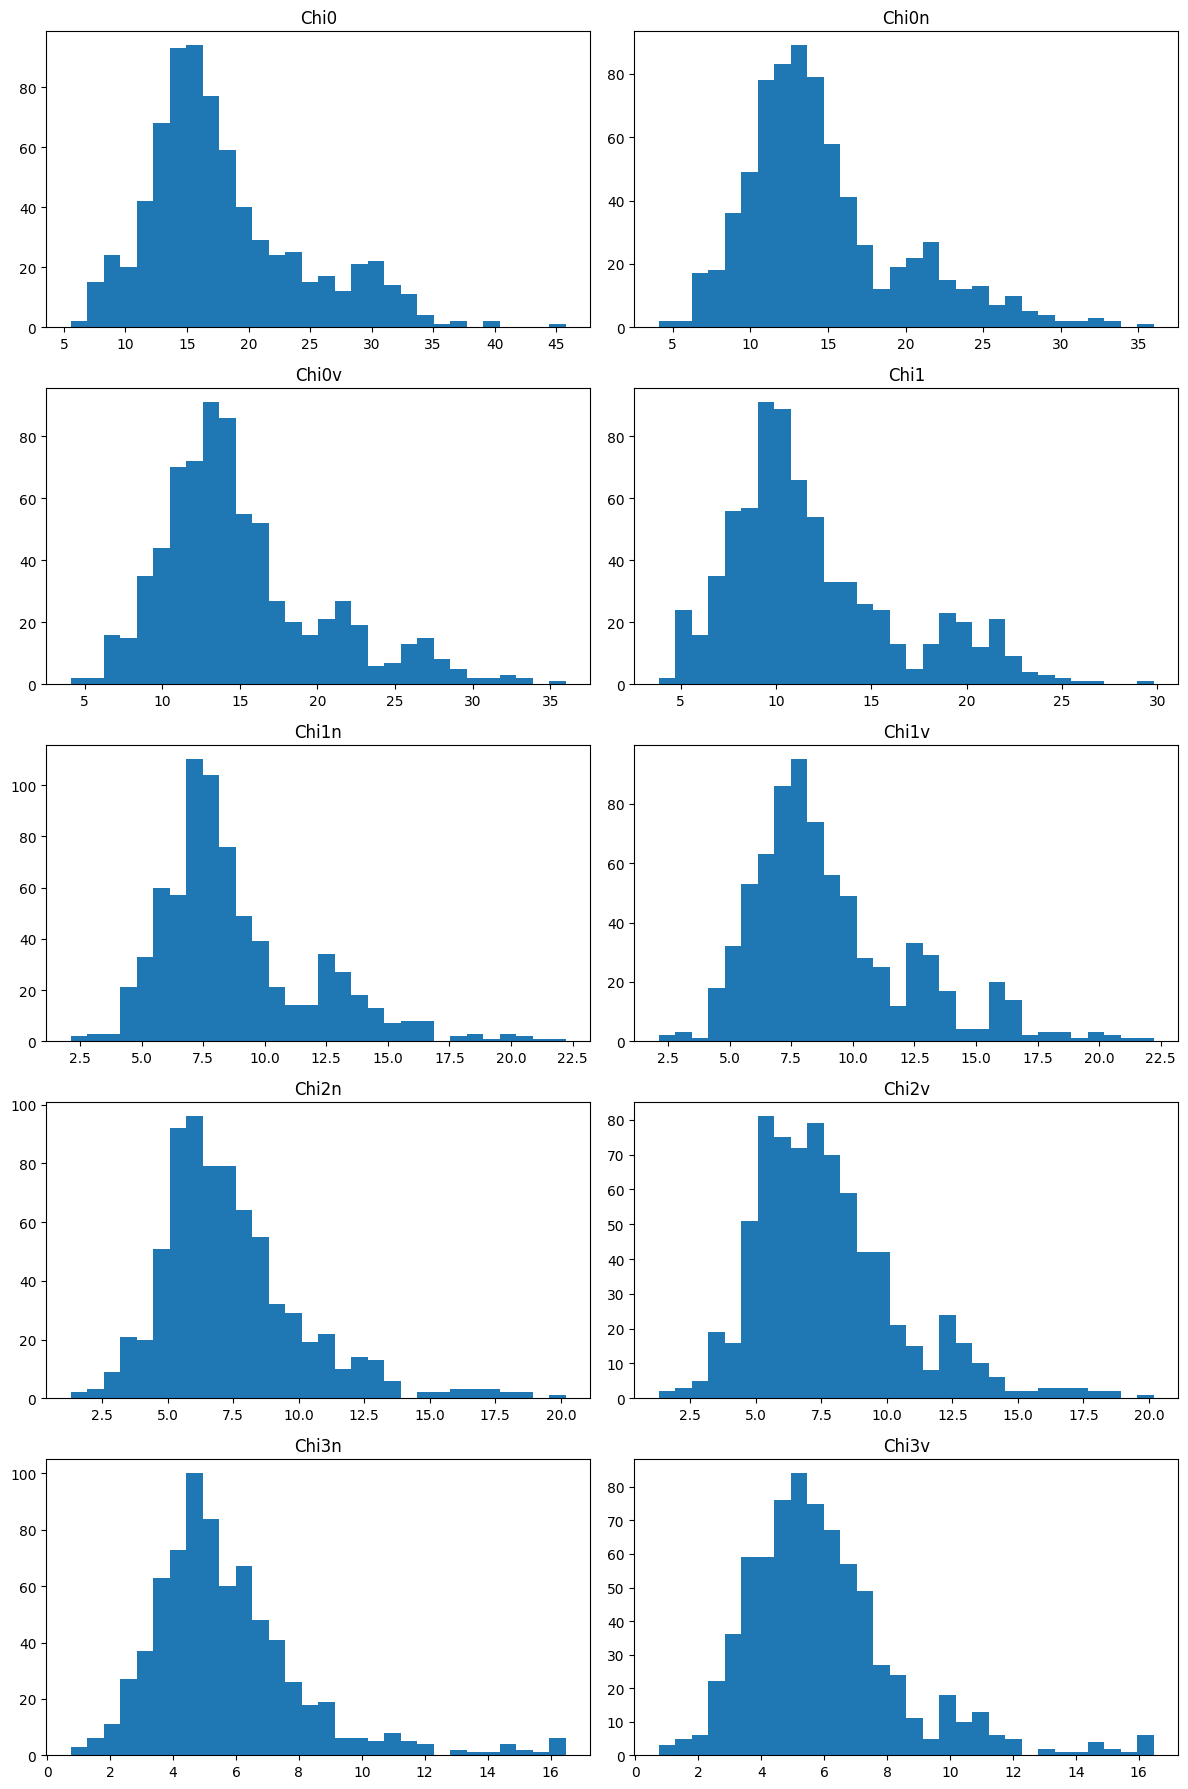

In [202]:
fig, axes = plt.subplots(5, 2, figsize=(12, 18))

for ax, col in zip(axes.flatten(), group_chi):

    ax.hist(df_train[col], bins=30)

    ax.set_title(col)

plt.tight_layout()
plt.show()

Kappa1–Kappa3 и большинство Chi-дескрипторов обладают умеренно правосторонней асимметрией: основная масса соединений сосредоточена в низких значениях, при этом присутствуют длинные хвосты.  

Ipc имеет экстремально широкий диапазон значений (max ≈ 3.95e13) и сильнейшую асимметрию, что делает его нестабильным для линейных моделей без логарифмирования.  

BertzCT также имеет выраженные выбросы и отражает общую структурную сложность молекулы.    

Дескрипторы числа колец (RingCount, NumAromaticRings, NumSaturatedRings и др.) являются дискретными признаками с ограниченным диапазоном значений.

В целом группа содержит как непрерывные сильно асимметричные признаки, так и дискретные структурные счётчики.

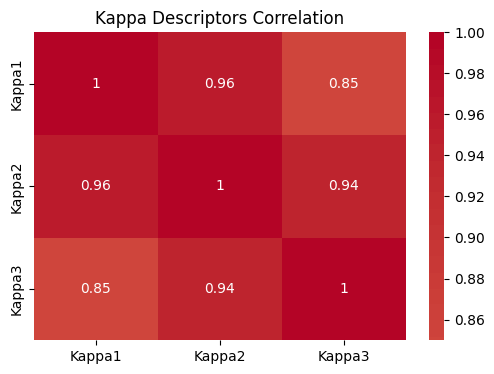

In [203]:
corr_kappa = df_train[group_kappa].corr()

plt.figure(figsize=(6, 4))

sns.heatmap(
    corr_kappa,
    annot=True,
    cmap='coolwarm',
    center=0
)

plt.title("Kappa Descriptors Correlation")
plt.show()

Анализ Kappa-дескрипторов показал очень высокую взаимную корреляцию между всеми признаками группы. Поскольку дескрипторы семейства Kappa описывают близкие структурные свойства, использование всех трёх одновременно может приводить к избыточности признакового пространства.

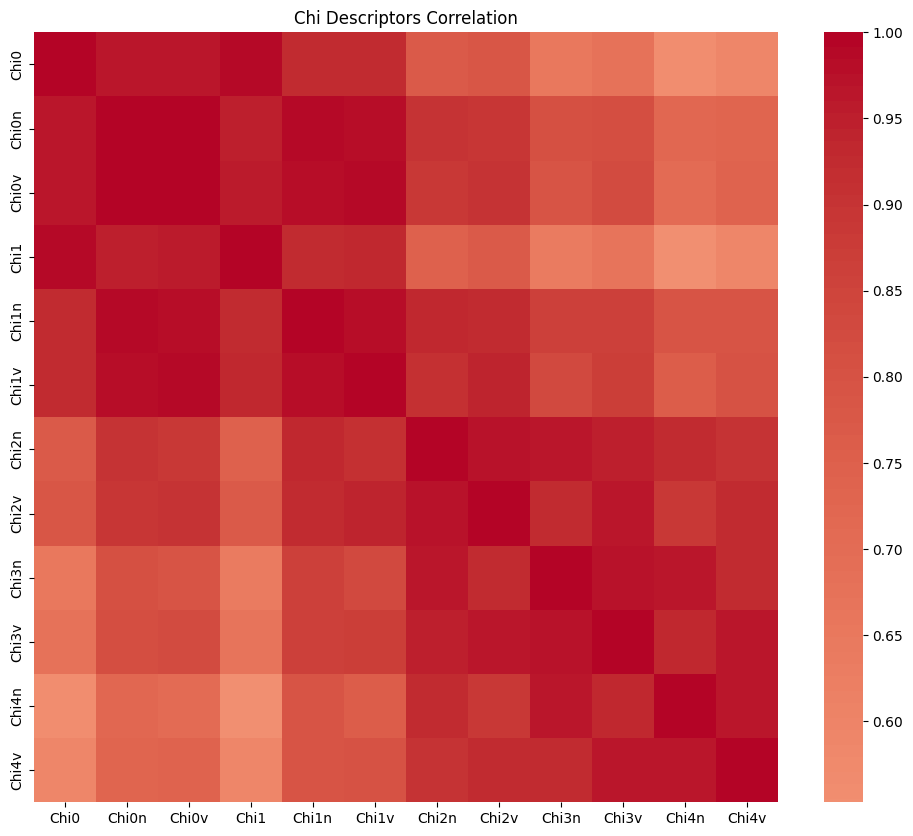

In [204]:
corr_chi = df_train[group_chi].corr()

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_chi,
    cmap='coolwarm',
    center=0
)

plt.title("Chi Descriptors Correlation")
plt.show()

Матрица корреляции Chi-дескрипторов показала крайне высокую корреляцию практически между всеми признаками группы (во многих случаях r > 0.9).  
  
Наличие столь высокой корреляции свидетельствует о выраженной мультиколлинеарности внутри группы и существенном дублировании информации.  

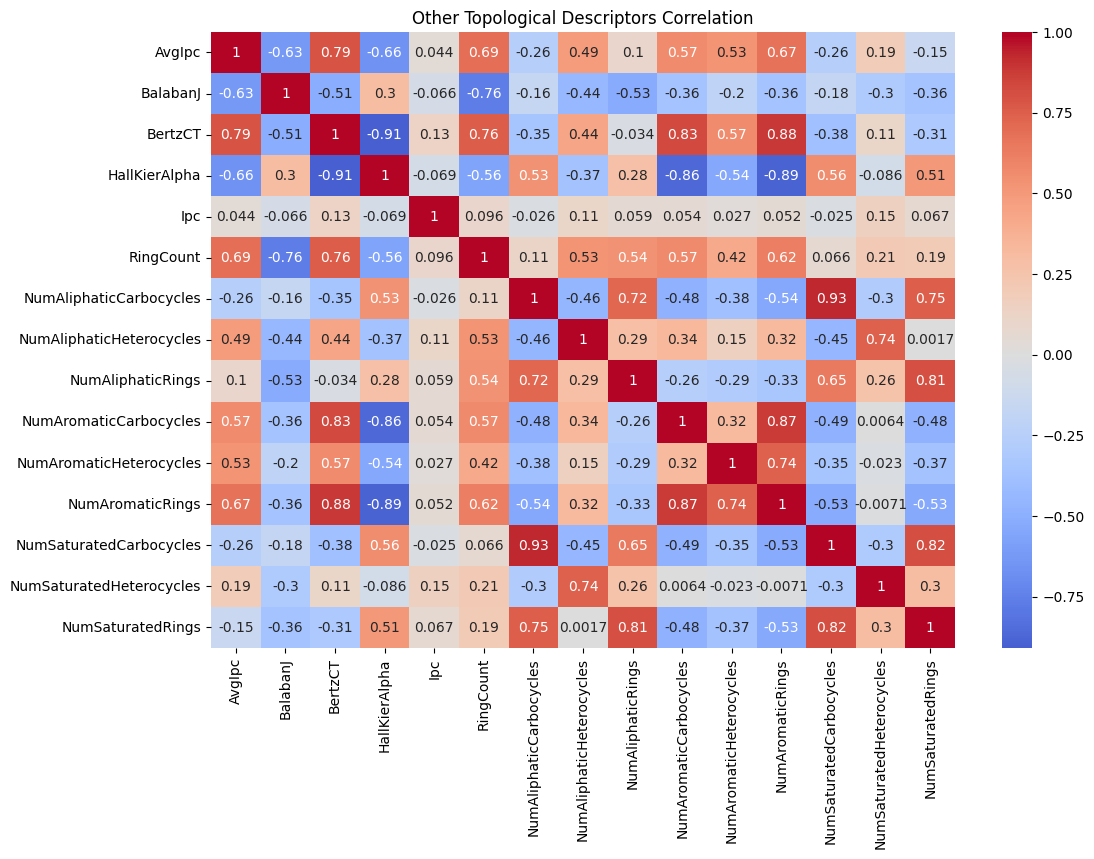

In [205]:
group_other_topological = [
    'AvgIpc',
    'BalabanJ',
    'BertzCT',
    'HallKierAlpha',
    'Ipc',

    *group_ring_descriptors
]

corr_other_topological = (
    df_train[group_other_topological]
    .corr()
)

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_other_topological,
    annot=True,
    cmap='coolwarm',
    center=0
)

plt.title("Other Topological Descriptors Correlation")
plt.show()

Анализ остальных топологических дескрипторов выявил как положительные, так и отрицательные взаимосвязи между признаками.Большинство признаков данной группы сохраняют самостоятельную химическую интерпретацию

In [206]:
for target in ["log_IC50, mM", "log_CC50, mM"]:

    print(target)

    display(
        df_train[group_topological_structural]
        .corrwith(df_train[target])
        .sort_values(
            key=np.abs,
            ascending=False
        )
    )

log_IC50, mM


NumSaturatedHeterocycles    0.274119
NumAliphaticHeterocycles    0.237659
NumAliphaticCarbocycles    -0.193360
Kappa3                     -0.171017
NumSaturatedCarbocycles    -0.170259
NumAromaticHeterocycles     0.155339
Chi2n                      -0.135525
Chi2v                      -0.130286
Chi4n                      -0.114217
Kappa2                     -0.113868
Chi4v                      -0.107905
NumAromaticRings            0.106803
Chi3n                      -0.102293
Chi1n                      -0.097596
Chi0n                      -0.097493
Kappa1                     -0.097103
Chi3v                      -0.095996
Chi0v                      -0.092207
Chi1v                      -0.092021
AvgIpc                      0.085812
RingCount                   0.077300
HallKierAlpha              -0.065119
BalabanJ                   -0.059205
Chi0                       -0.051601
BertzCT                     0.042642
NumAromaticCarbocycles      0.038171
Chi1                       -0.028539
N

log_CC50, mM


Kappa3                     -0.266513
Kappa2                     -0.213676
Kappa1                     -0.198532
Chi0                       -0.173496
Chi0n                      -0.171626
Chi0v                      -0.171505
Chi1v                      -0.165529
Chi1n                      -0.163561
Chi2v                      -0.158760
Chi1                       -0.153821
Chi2n                      -0.152225
NumSaturatedHeterocycles    0.142592
NumAromaticCarbocycles     -0.136660
Chi4v                      -0.123045
NumAromaticHeterocycles     0.122710
Chi4n                      -0.117276
BertzCT                    -0.107683
NumAliphaticHeterocycles    0.099037
HallKierAlpha               0.097510
Chi3v                      -0.086673
NumAliphaticCarbocycles    -0.082749
Chi3n                      -0.080510
NumSaturatedRings           0.076632
RingCount                  -0.040225
NumAromaticRings           -0.034151
AvgIpc                      0.028521
BalabanJ                   -0.020932
I

Полученные результаты показывают, что дескрипторы, характеризующие форму, разветвлённость и топологическую сложность молекулы, в большей степени связаны с цитотоксичностью, чем с противовирусной активностью.

При этом абсолютные значения коэффициентов корреляции остаются относительно невысокими (|r| < 0.3), что свидетельствует об отсутствии выраженных линейных зависимостей и указывает на вероятный нелинейный характер связи между топологическими характеристиками молекул и биологическими свойствами.

In [207]:
topology_to_drop = [

    # Kappa
    'Kappa1',
    'Kappa2',

    # Chi
    'Chi0',
    'Chi0v',

    'Chi1',
    'Chi1v',

    'Chi2v',
    'Chi3v',
    'Chi4v',
]

df_train = df_train.drop(columns=topology_to_drop, errors='ignore')

## ГРУППА 4: Поверхностные дескрипторы (VSA)

## ГРУППА 5: Функциональные группы

## ГРУППА 6: Специфические дескрипторы

In [208]:
df_train[group_specific_descriptors].describe().T

,count,mean,std,min,25%,50%,75%,max
MaxAbsEStateIndex,734.0,10.908605,3.332662,2.321942,9.791801,12.218221,13.219973,15.933463
MaxEStateIndex,734.0,10.908605,3.332662,2.321942,9.791801,12.218221,13.219973,15.933463
MinAbsEStateIndex,734.0,0.179374,0.169706,0.000039,0.046742,0.120437,0.294239,1.374614
MinEStateIndex,734.0,-0.976096,1.594380,-6.992796,-1.332714,-0.419485,0.018077,1.374614
BCUT2D_MWHI,734.0,23.362410,14.750494,14.513946,16.368274,16.564091,32.092047,126.912704
BCUT2D_MWLOW,734.0,9.783579,0.514164,0.931261,9.688742,9.716213,9.967378,10.708899
BCUT2D_CHGHI,734.0,2.474088,0.155186,1.834460,2.391891,2.505196,2.590834,2.822293
BCUT2D_CHGLO,734.0,-2.350571,0.163624,-2.721859,-2.476825,-2.359828,-2.242732,-1.713605
BCUT2D_LOGPHI,734.0,2.472953,0.151878,1.932099,2.369719,2.484927,2.601648,2.791427
BCUT2D_LOGPLOW,734.0,-2.409419,0.173837,-2.785712,-2.531383,-2.398386,-2.325698,-1.647760


Группа дескрипторов EState, BCUT2D и Morgan density характеризуется умеренной вариабельностью и наличием отдельных экстремальных значений.  
BCUT2D-дескрипторы характеризуются различными диапазонами и масштабами значений. Наиболее широкий разброс наблюдается у BCUT2D_MWHI, что связано с вариабельностью молекулярных масс и размеров соединений.

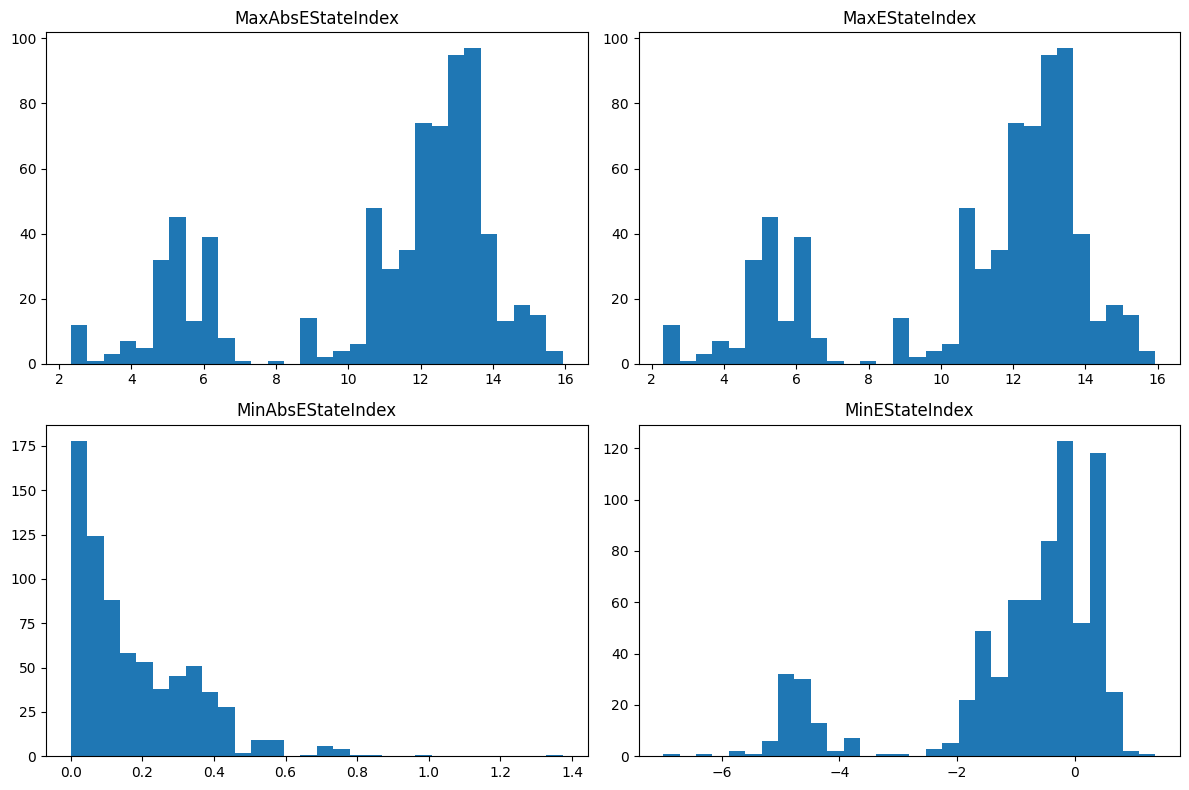

In [209]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(axes.flatten(), group_estate_indices):

    ax.hist(df_train[col], bins=30)

    ax.set_title(col)

plt.tight_layout()
plt.show()

Гистограммы EState-дескрипторов демонстрируют неоднородные распределения и наличие асимметрии. Дескрипторы MaxAbsEStateIndex и MaxEStateIndex имеют практически идентичные распределения

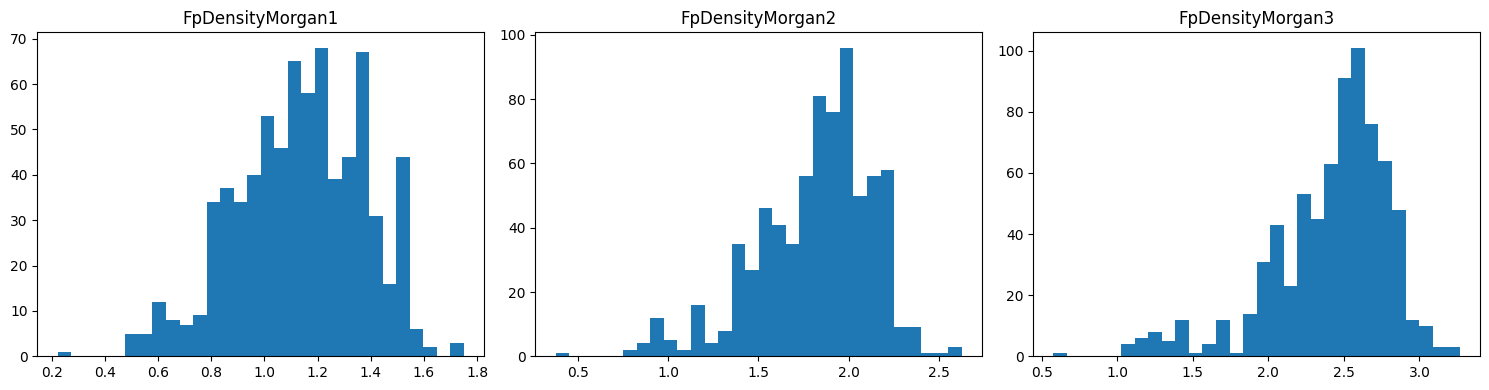

In [210]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes.flatten(), group_morgan_density):

    ax.hist(df_train[col], bins=30)

    ax.set_title(col)

plt.tight_layout()
plt.show()

Распределения FpDensityMorgan1, FpDensityMorgan2 и FpDensityMorgan3 являются относительно стабильными и близкими к одномодальным. С увеличением радиуса Morgan fingerprint наблюдается закономерный сдвиг распределений вправо и рост средних значений.

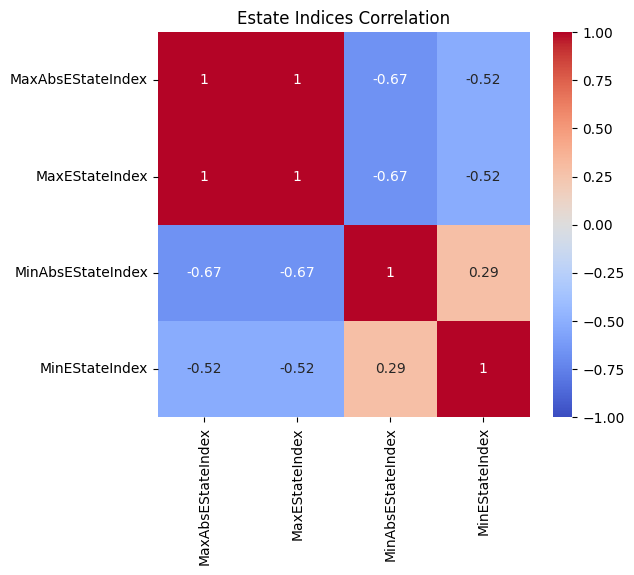

In [211]:
corr_estate = df_train[group_estate_indices].corr()

plt.figure(figsize=(6, 5))

sns.heatmap(
    corr_estate,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1
)

plt.title("Estate Indices Correlation")
plt.show()


Корреляционный анализ показал наличие сильной мультиколлинеарности внутри группы EState-дескрипторов. Наиболее выраженная зависимость наблюдается между MaxAbsEStateIndex и MaxEStateIndex (r ≈ 1.00), что свидетельствует о полном дублировании информации.

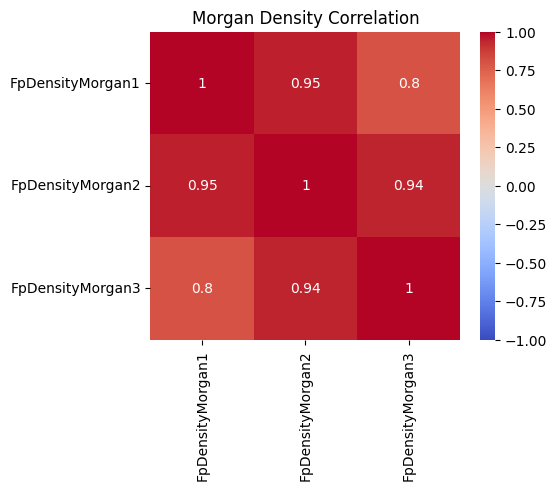

In [212]:
corr_morgan = df_train[group_morgan_density].corr()

plt.figure(figsize=(5, 4))

sns.heatmap(
    corr_morgan,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1
)

plt.title("Morgan Density Correlation")
plt.show()


Дескрипторы Morgan density демонстрируют очень высокую взаимную корреляцию, что указывает на выраженную мультиколлинеарность и значительную избыточность информации внутри группы.

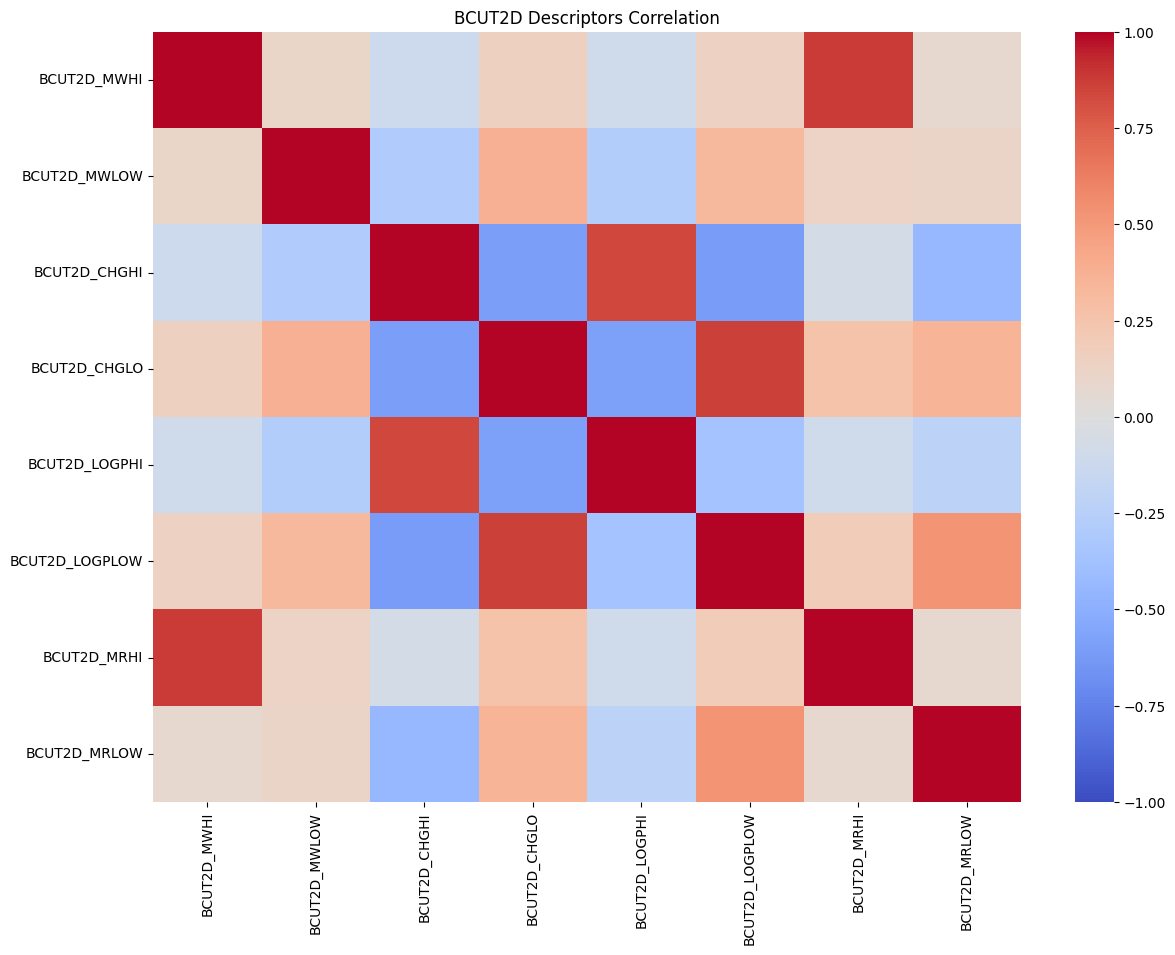

In [213]:
corr_bcut = df_train[group_bcut].corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr_bcut,
    cmap='coolwarm',
    vmin=-1,
    vmax=1
)

plt.title("BCUT2D Descriptors Correlation")
plt.show()

Анализ корреляционной матрицы BCUT2D-дескрипторов показал, что между разными группами преобладают слабые и умеренные корреляции, что свидетельствует о достаточно хорошей ортогональности дескрипторов. Набор BCUT2D-дескрипторов несёт достаточно разнообразную информацию о молекуле высокой мультиколлинеарности не обнаружено, удаление не требуетсяя 

In [214]:
for target in ["log_IC50, mM", "log_CC50, mM"]:

    print(target)

    display(
        df_train[group_specific_descriptors]
        .corrwith(df_train[target])
        .sort_values(
            key=np.abs,
            ascending=False
        )
    )

log_IC50, mM


BCUT2D_MWLOW         0.166509
BCUT2D_CHGLO         0.136991
MinEStateIndex      -0.130750
FpDensityMorgan3     0.119389
MaxAbsEStateIndex    0.114405
MaxEStateIndex       0.114405
BCUT2D_LOGPLOW       0.089644
FpDensityMorgan2     0.088703
BCUT2D_LOGPHI       -0.066024
FpDensityMorgan1     0.054593
BCUT2D_MRHI          0.040171
BCUT2D_MWHI          0.036246
MinAbsEStateIndex   -0.032873
BCUT2D_CHGHI         0.011815
BCUT2D_MRLOW        -0.009712
dtype: float64

log_CC50, mM


FpDensityMorgan2     0.160178
FpDensityMorgan1     0.156530
BCUT2D_CHGLO         0.135368
BCUT2D_LOGPLOW       0.132004
FpDensityMorgan3     0.112916
BCUT2D_CHGHI         0.078359
BCUT2D_MWLOW         0.072177
BCUT2D_LOGPHI        0.064579
MaxAbsEStateIndex   -0.050494
MaxEStateIndex      -0.050494
MinAbsEStateIndex    0.044628
BCUT2D_MRHI         -0.016759
BCUT2D_MWHI         -0.015768
MinEStateIndex       0.014424
BCUT2D_MRLOW         0.009485
dtype: float64

Связь с целевыми переменными (log_IC50, log_CC50) остаётся слабой. Максимальные абсолютные корреляции не превышают ~0.13, что указывает на ограниченную линейную предсказательную способность EState-дескрипторов.

Связь с целевыми переменными слабая, однако FpDensityMorgan2 показывает наиболее стабильные корреляции с log_CC50 (r ≈ 0.16) и умеренную связь с log_IC50.  
  
Наиболее выраженную связь с целевыми переменными показывают: BCUT2D_CHGLO, BCUT2D_LOGPLOW, BCUT2D_MWLOW.

Несмотря на слабые абсолютные значения корреляций (до ~0.17), BCUT-дескрипторы могут быть полезны в нелинейных моделях благодаря комплексному описанию электронной структуры молекул.  

In [215]:
features_to_drop = [

    # EState descriptors
    'MaxAbsEStateIndex',

    # Morgan density descriptors
    'FpDensityMorgan1',
    'FpDensityMorgan3'

]

df_train = df_train.drop(columns=features_to_drop)